In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from data_downloader import get_market_data

# Market Strategies Comparison Notebook

This notebook explores and compares several investment strategies using historical market data:

1. **Leveraged SPY ETF vs Regular SPY**  
    Analyze the performance differences between a leveraged SPY ETF and the standard SPY index. Visualizations and metrics will highlight risk and return profiles.

2. **ML/LLM-Generated Strategy vs Index**  
    Implement a typical strategy generated by machine learning or large language models. Compare its results against major indices (e.g., SPY, QQQ) to evaluate predictive power and robustness.

3. **Momentum Strategy**  
    Construct and backtest a momentum-based strategy designed to outperform the market. Assess its effectiveness using return, volatility, and drawdown statistics.

Throughout the notebook, we will use Python and pandas for data manipulation, and visualize results to facilitate clear, actionable insights.

In [2]:
tickers = get_tickers(mod="1.1")

tickers

['AMZN', 'NVDA']

In [3]:
# DataFrame to store everything
df_prices = pd.DataFrame()

for ticker in tickers:
    df = get_market_data(
        ticker=ticker, 
        start_date='2010-01-01', 
        end_date='2025-01-01', 
        returns=False
    )
    
    prices = df['close'].rename(ticker)
    
    df_prices = pd.concat([df_prices, prices], axis=1)
    
    print(f'Data Ready for {ticker}')

Data Ready for AMZN
Data Ready for NVDA


In [4]:
# Get historical price data for VOO and leveraged SPY ETF (e.g., SSO for 2x leveraged SPY)
voo_df = get_market_data(
    ticker='VOO',
    start_date='2011-01-01',
    end_date='2025-09-05',
    returns=False
)

sso_df = get_market_data(
    ticker='SSO',
    start_date='2011-01-01',
    end_date='2025-09-05',
    returns=False
)

# Calculate daily returns
voo_returns = voo_df['close'].pct_change().dropna().to_frame(name='VOO_Return')
sso_returns = sso_df['close'].pct_change().dropna().to_frame(name='SSO_Return')

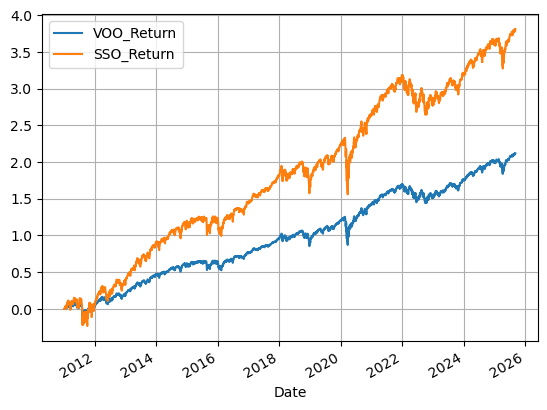

In [5]:
ax=voo_returns.cumsum().plot();
sso_returns.cumsum().plot(ax=ax, grid=True);

In [6]:
# We can use StatsModels efficiently to get the betas for the whole history
import statsmodels.api as sm
import numpy as np
from factors_toolkit import wexp

betas_list = []
tickers = ['SSO']
# Loop to Obtain Betas and Alpha + Residuals
for ticker in tickers:
    # Define series
    y_series = sso_returns.dropna()
    
    # Set the Window
    window = len(y_series)
    weights = window * wexp(window, window/2)
    
    # Define weights
    model = sm.WLS(y_series, voo_returns.loc[y_series.index], weights=weights)
    results = model.fit()
    
    beta = results.params.iloc[0]
    
    betas_list.append(beta)

# Create Beta Series
betas_series = pd.Series(betas_list, index=tickers)
betas_series.name = 'history_beta'

betas_series

SSO    1.993177
Name: history_beta, dtype: float64

In [7]:
voo_returns.dropna()

,VOO_Return
Date,
2011-01-04,-0.000861
2011-01-05,0.005339
2011-01-06,-0.001713
2011-01-07,-0.002059
2011-01-10,-0.000860
...,...
2025-08-28,0.003533
2025-08-29,-0.005767
2025-09-02,-0.007368


In [8]:
sso_returns.dropna()

,SSO_Return
Date,
2011-01-04,-0.001429
2011-01-05,0.010429
2011-01-06,-0.003643
2011-01-07,-0.003859
2011-01-10,-0.002651
...,...
2025-08-28,0.006706
2025-08-29,-0.012197
2025-09-02,-0.015103


In [9]:
# Let us get the betas of each stock
from regression_toolkit import rolling_wls_regression, add_constant

voo_returns_const = add_constant(voo_returns)
sso_returns_const = add_constant(sso_returns)


coefficients = rolling_wls_regression(
    sso_returns_const.dropna(),
    voo_returns_const.dropna()
)

coefficients

{'alphas':             constant  SSO_Return
 Date                            
 2012-01-03       1.0   -0.000050
 2012-01-04       1.0   -0.000057
 2012-01-05       1.0   -0.000058
 2012-01-06       1.0   -0.000058
 2012-01-09       1.0   -0.000062
 ...              ...         ...
 2025-08-28       1.0   -0.000259
 2025-08-29       1.0   -0.000262
 2025-09-02       1.0   -0.000263
 2025-09-03       1.0   -0.000260
 2025-09-04       1.0   -0.000258
 
 [3438 rows x 2 columns],
 'betas':                 constant  SSO_Return
 Date                                
 2012-01-03  0.000000e+00    2.008339
 2012-01-04  0.000000e+00    2.008306
 2012-01-05  0.000000e+00    2.008295
 2012-01-06  0.000000e+00    2.008291
 2012-01-09  2.220446e-16    2.008278
 ...                  ...         ...
 2025-08-28  8.881784e-16    2.008168
 2025-08-29  0.000000e+00    2.008288
 2025-09-02  0.000000e+00    2.008313
 2025-09-03  0.000000e+00    2.008358
 2025-09-04  0.000000e+00    2.008473
 
 [3438 rows x 2

C:\Users\edgar\AppData\Local\Temp\ipykernel_22132\4104138123.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: sm.OLS(x, sm.add_constant(returns_df['VOO_Return'][x.index])).fit().params[1]
C:\Users\edgar\AppData\Local\Temp\ipykernel_22132\4104138123.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: sm.OLS(x, sm.add_constant(returns_df['VOO_Return'][x.index])).fit().params[1]
C:\Users\edgar\AppData\Local\Temp\ipykernel_22132\4104138123.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent 

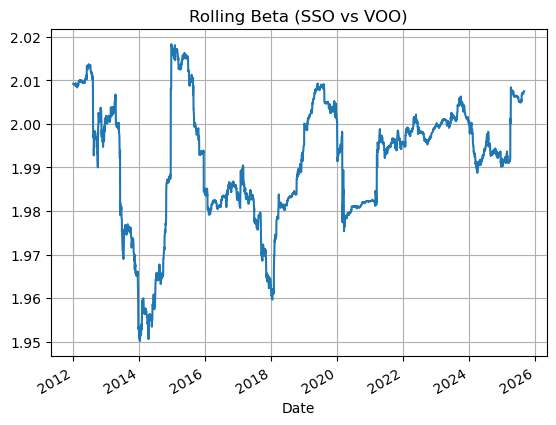

In [10]:
import statsmodels.api as sm

# Align indexes and drop missing values
returns_df = pd.concat([sso_returns, voo_returns], axis=1).dropna()

window = 252  # 1-year rolling window (trading days)
rolling_beta = returns_df['SSO_Return'].rolling(window).apply(
    lambda x: sm.OLS(x, sm.add_constant(returns_df['VOO_Return'][x.index])).fit().params[1]
)

rolling_beta.plot(title='Rolling Beta (SSO vs VOO)', grid=True);

In [12]:
betas_df = coefficients['betas']
betas_df

,constant,SSO_Return
Date,,
2012-01-03,0.000000e+00,2.008339
2012-01-04,0.000000e+00,2.008306
2012-01-05,0.000000e+00,2.008295
2012-01-06,0.000000e+00,2.008291
2012-01-09,2.220446e-16,2.008278
...,...,...
2025-08-28,8.881784e-16,2.008168
2025-08-29,0.000000e+00,2.008288
2025-09-02,0.000000e+00,2.008313


In [13]:
from factors_toolkit import compute_factor_contributions, compute_residual_returns

# Cut DataFrames
# Create Beta's DataFrame
betas_df = coefficients['betas']
stock_beta = betas_df['SSO_Return']
r_i = sso_returns['SSO_Return'].loc[stock_beta.index]
r_m = voo_returns['VOO_Return'].loc[stock_beta.index]

# Calculate factor returns
r_f = compute_factor_contributions(r_m, stock_beta)

# Calculate residual returns
residual_returns = compute_residual_returns(r_i, r_m, stock_beta)
residual_returns.name = 'residual_returns'

residual_returns


Date
2012-01-03    0.001111
2012-01-04   -0.000935
2012-01-05   -0.000277
2012-01-06   -0.000032
2012-01-09   -0.000594
                ...   
2025-08-28   -0.000388
2025-08-29   -0.000616
2025-09-02   -0.000305
2025-09-03   -0.000046
2025-09-04   -0.000015
Name: residual_returns, Length: 3438, dtype: float64

In [14]:
r_m

Date
2012-01-03    0.014796
2012-01-04    0.001715
2012-01-05    0.003254
2012-01-06   -0.002048
2012-01-09    0.001539
                ...   
2025-08-28    0.003533
2025-08-29   -0.005767
2025-09-02   -0.007368
2025-09-03    0.005113
2025-09-04    0.008230
Name: VOO_Return, Length: 3438, dtype: float64

In [15]:
r_f

Date
2012-01-03    0.029715
2012-01-04    0.003444
2012-01-05    0.006535
2012-01-06   -0.004114
2012-01-09    0.003091
                ...   
2025-08-28    0.007095
2025-08-29   -0.011581
2025-09-02   -0.014798
2025-09-03    0.010268
2025-09-04    0.016530
Length: 3438, dtype: float64

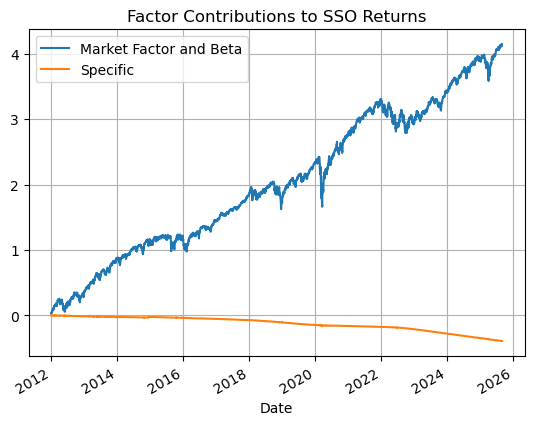

In [16]:
ax=r_f.cumsum().plot(title='Factor Contributions to SSO Returns', grid=True);
residual_returns.cumsum().plot(ax=ax, grid=True);
ax.legend(['Market Factor and Beta', 'Specific']);